From the `Bamboo_setup` directory, run the following command:
```bash
jupyter notebook --no-browser --port=8888
```
Copy the URL starting with `http://localhost:8888/`.
When picking the kernel for this notebook, click **Existing Jupyter Server** and paste the URL.

In [1]:
import sys
from pathlib import Path
BAMBOO_SETUP = Path.cwd()
sys.path.append(str((BAMBOO_SETUP/'src').resolve()))
import pandas as pd
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.width', 1000)  # Set a larger width to fit the editor window
# pd.set_option('display.max_colwidth', None)  # Allow columns to be fully displayed

In [2]:
Z_OUTPUT_eos = Path('/eos/user/a/anunezde/Z_OUTPUT_eos')
workdir = Z_OUTPUT_eos / '2022_even_0822' / 'LLR_and_vars_4o5'
sel_name = 'SL_res_2b_x'
models_yml = 'config/NN_quick_run.yml'
total_inputs = 'input/8llrs1D.txt'

# Setup a DNN Manager to load all the data

2024-10-18 21:10:08.484692: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-18 21:10:08.538298: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Welcome to JupyROOT 6.30/02
DNN Manager instantiated:
	WORKDIR:/eos/user/a/anunezde/Z_OUTPUT_eos/2022_even_0822/LLR_and_vars_4o5
	DNNMANAGERDIR:/eos/user/a/anunezde/Z_OUTPUT_eos/2022_even_0822/LLR_and_vars_4o5/DNNManager_check_m9999
	Total inputs file: /afs/cern.ch/user/a/anunezde/bamboodev/hh/Bamboo_setup/src/post_processing/NN/input/8llrs1D.txt
	Config models file: /afs/cern.ch/user/a/anunezde/bamboodev/hh/Bamboo_setup/src/post_processing/NN/config/NN_quick_run.yml

Loading model configs from: NN_quick_run.yml
	Loading data ...

Preprocessing data ...
After removing events with negative weights:
LLRs were found in the loaded data.
Replacing nan values with -9999
Total_df:
            event     genWeight  bjet0_pt_llr  bjets_dEta_llr  bjets_dPhi_llr  bjets_dR_llr  bjets_mbb_llr  mjj_llr  trijet_mInv_llr  trijet_pt_rat_llr          File  Process_DY  Process_HH_bbWW  Process_HH_bbtautau  Process_VV  Process_WJets  Process_tW  Process_ttbar
186577         18      3.805950        -0.278  

Could not search for non-variable resources. Concrete function internal representation may have changed.
2024-10-18 21:12:11.058350: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2024-10-18 21:12:11.058557: I tensorflow/core/grappler/clusters/single_machine.cc:357] Starting new session
2024-10-18 21:12:11.990362: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2024-10-18 21:12:11.990640: I tensorflow/core/grappler/clusters/single_machine.cc:357] Starting new session


	Evaluating model and predicting ...
{'loss': 0.5663299560546875, 'accuracy': 0.8542493581771851, 'precision': 0.8552389144897461, 'recall': 0.8478531241416931, 'auc_roc': 0.9367498159408569, 'auc_pr': 0.8518761396408081, 'f1_score_macro': 0.32137709856033325, 'f1_score_micro': 0.8542493581771851, 'precision_HH': 0.0, 'recall_HH': 0.0, 'precision_ttbar': 0.8553482294082642, 'recall_ttbar': 0.992314338684082, 'precision_tW': 0.4653465449810028, 'recall_tW': 0.0008789482526481152}
11609/11609 [==============================] - 19s 2ms/step
	Predictions:
      event  Class_HH  Class_ttbar  Class_tW  Score_HH  Score_ttbar  Score_tW
0  22503358       0.0          1.0       0.0  0.097354     0.629542  0.273104
1  57385234       0.0          1.0       0.0  0.053644     0.669202  0.277154
2  17528158       0.0          1.0       0.0  0.030455     0.628982  0.340563
3  11242832       0.0          1.0       0.0  0.122852     0.594559  0.282589
4    915896       0.0          1.0       0.0  0.0366

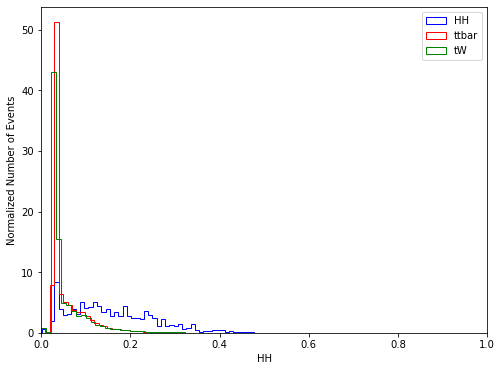

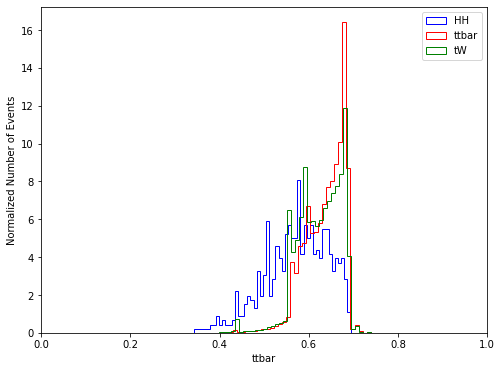

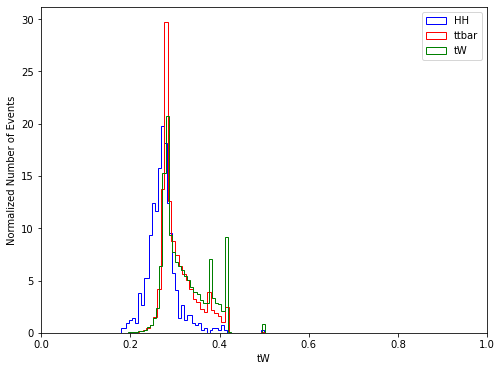

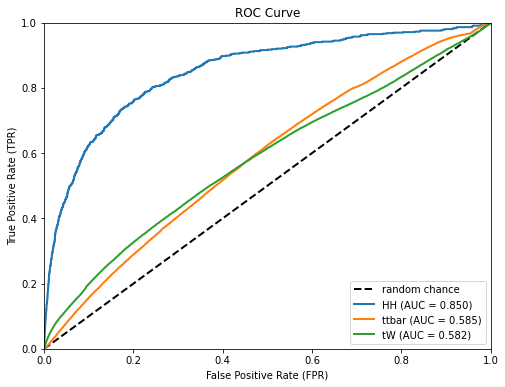

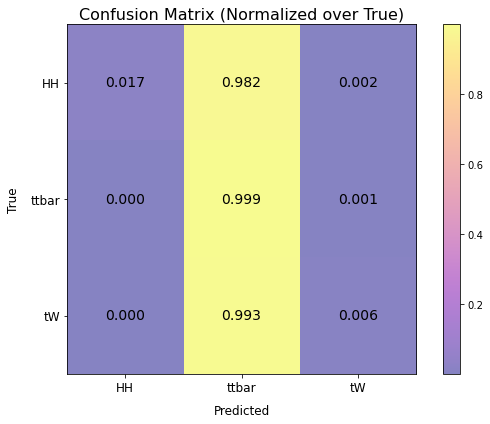

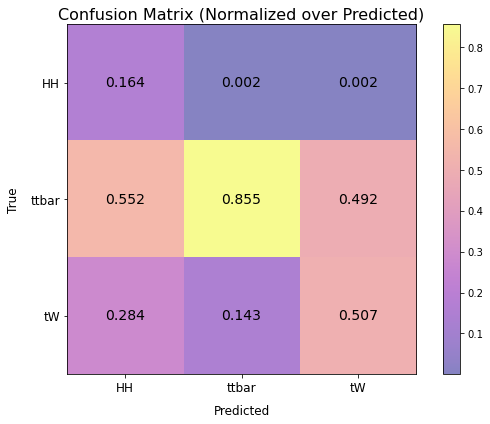

In [3]:
from post_processing.NN.DNNManager import DNNManager
manager = DNNManager(workdir=workdir, sel_name=sel_name, models_yml=models_yml, total_inputs=total_inputs, DNNManagerdir='DNNManager_check_p9999')
manager.set_mode(mode = 'train_eval', rank_features=False)
manager.mask_value = 9999
manager.Run()

In [ ]:
manager2 = DNNManager(workdir=workdir, sel_name=sel_name, models_yml=models_yml, total_inputs=total_inputs, DNNManagerdir='DNNManager_check_m9999_2')
manager2.set_mode(mode = 'train_eval', rank_features=False)
manager2.Run()